# Exploratory Data Analysis: Restaurant Performance & Server Anomalies

## Descripción del proyecto

El objetivo de este proyecto es realizar un análisis exploratorio / forense de datos (EDA) sobre las ventas de un restaurante durante el periodo 2014-2015. El reto principal fue identificar inconsistencias operativas y analizar la productividad del personal de servicio.

Preparación del entorno:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('restaurante.xlsx')

print(f'Número de filas: {df.shape[0]}')
print(f'Número de columnas: {df.shape[1]}')

Número de filas: 30132
Número de columnas: 12


Agregar una columna llamada "FechaMes", que contenga el año y el mes de la columna fecha (Ej. 2010-03)

In [2]:
df['FechaMes'] = df.Fecha.dt.strftime('%Y-%m')
df.head()

,Orden,Fecha,Hora de Cobro,Mesa,Atendió,Tipo,Producto,Categoria,Precio,Costo,Propina,Tipo de Cliente,FechaMes
0,1,2014-02-01,18:43:12,1,Rodolfo,Bebida,Tecate,Cervezas,25,18.00,0.07,Cliente Nuevo,2014-02
1,1,2014-02-01,18:43:12,1,Rodolfo,Bebida,Tisana,Bebida no Alcohol,25,18.00,0.07,Cliente Nuevo,2014-02
2,1,2014-02-01,18:43:12,1,Rodolfo,Bebida,Café americano,Bebida no Alcohol,18,12.60,0.07,Cliente Nuevo,2014-02
3,1,2014-02-01,18:43:12,1,Rodolfo,Bebida,Te helado,Bebida no Alcohol,25,18.50,0.07,Cliente Nuevo,2014-02
4,1,2014-02-01,18:43:12,1,Rodolfo,Comida,Pera Rostizada,Ensaladas,89,75.65,0.07,Cliente Nuevo,2014-02


Investigaremos si el ingreso ha bajado, obteneniendo las ventas totales de cada mes:

In [3]:
df.groupby('FechaMes').agg({'Precio':'sum'})


,Precio
FechaMes,
2014-02,158871
2014-03,199750
2014-04,205472
2014-05,160516
2014-06,190253
2014-07,182819
2014-08,176184
2014-09,155277
2014-10,166222


Harémos una inspección rápida de los datos con una gráfica de calor sobre las ventas de cada mes:

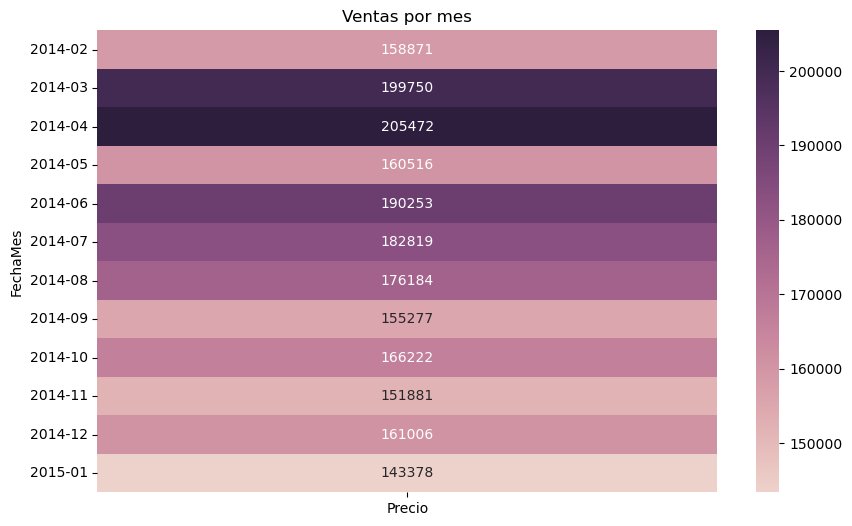

In [4]:
heat_map = df.groupby('FechaMes').agg({'Precio':'sum'})
plt.figure(figsize=(10,6))

sns.heatmap(heat_map, annot=True, fmt='.0f', cmap= sns.cubehelix_palette(as_cmap=True))

plt.title('Ventas por mes')
plt.show()


Hacemos una gráfica de barras con las ventas de cada mes:

<Axes: xlabel='FechaMes'>

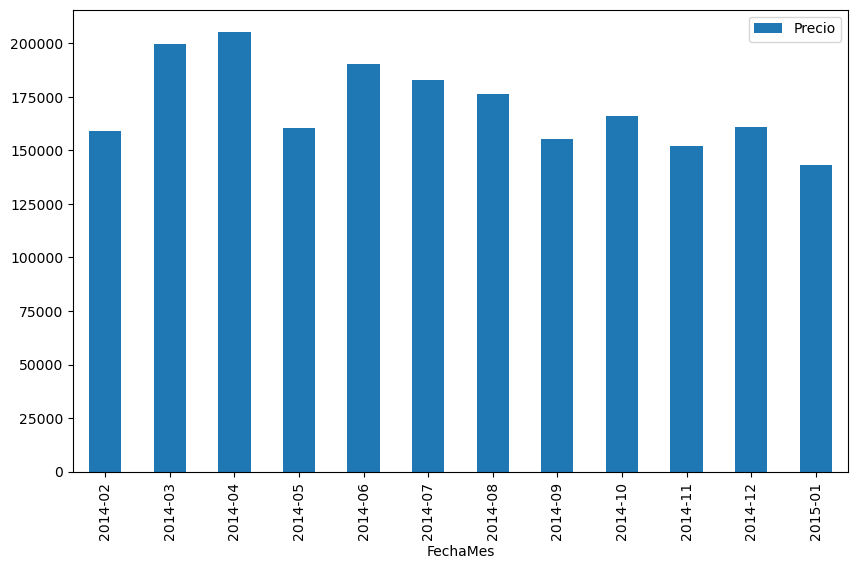

In [5]:
df.groupby('FechaMes').agg({'Precio':'sum'}).plot(kind= 'bar', figsize=(10,6))

__Conclusión:__ los ingresos aumentaron al principio, pero volvieron a bajar a niveles record.

Ahora contaremos cuantos productos se sirvieron en cada mes:

In [6]:
grouped = df.groupby('FechaMes').agg({'Producto':'count'})
display(grouped)

,Producto
FechaMes,
2014-02,2427
2014-03,2879
2014-04,2692
2014-05,2244
2014-06,2580
2014-07,2488
2014-08,2399
2014-09,2467
2014-10,2519


Crearemos un gráfico de calor sobre la cantidad de platos vendidos en cada mes para hacer un análisis exploratorio sencillo:

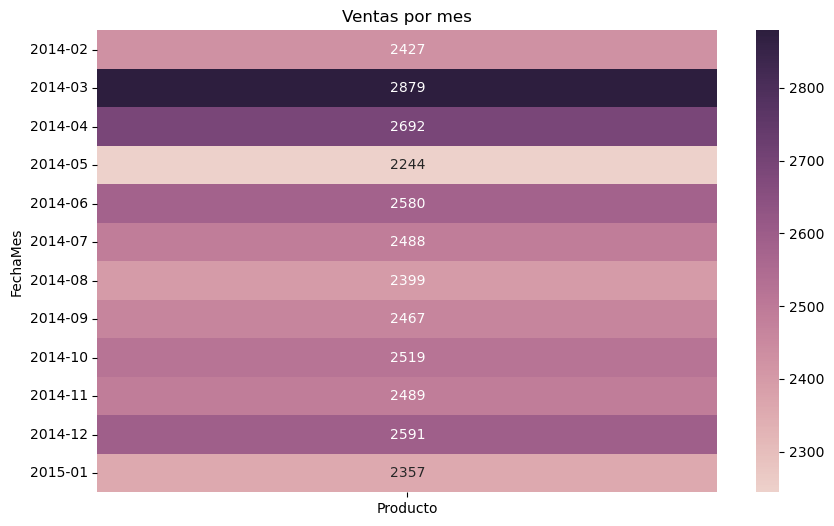

In [7]:
plt.figure(figsize=(10,6))

sns.heatmap(grouped, annot=True, fmt='.0f', cmap= sns.cubehelix_palette(as_cmap=True))

plt.title('Ventas por mes')
plt.show()

Haremos una gráfica de linea con el total de productos servidos por mes:

<Axes: xlabel='FechaMes'>

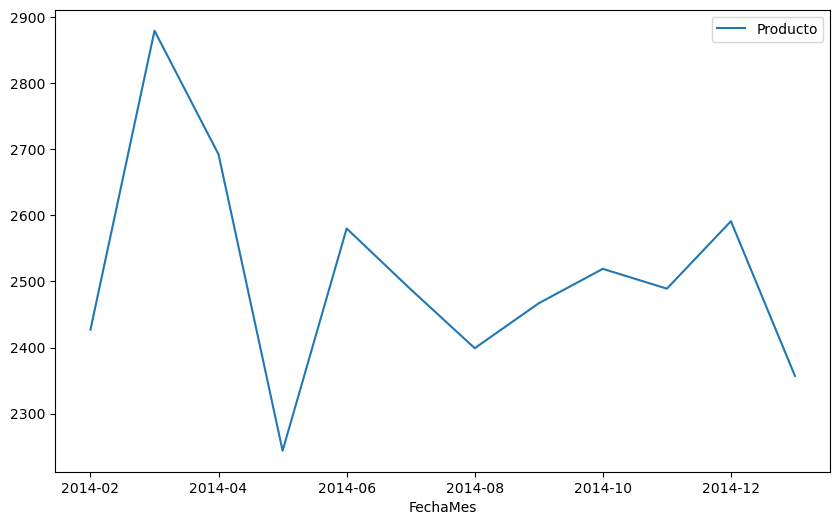

In [8]:
grouped.plot(kind= 'line', figsize=(10,6))

__Conclusión:__ los ingresos bajaron, pero la cantidad de productos vendidos se mantuvo en el tiempo

Ahora mostraremos los ingresos al mes según si es comida o bebida, para encontrar si hubo un cambio en los habitos de consumo de los clientes:

In [9]:
tipo_pivot = df.pivot_table(index='FechaMes',columns='Tipo', values='Precio', aggfunc='sum')

Graficaremos el ingreso mensual de cada tipo de alimento:

<Axes: xlabel='FechaMes'>

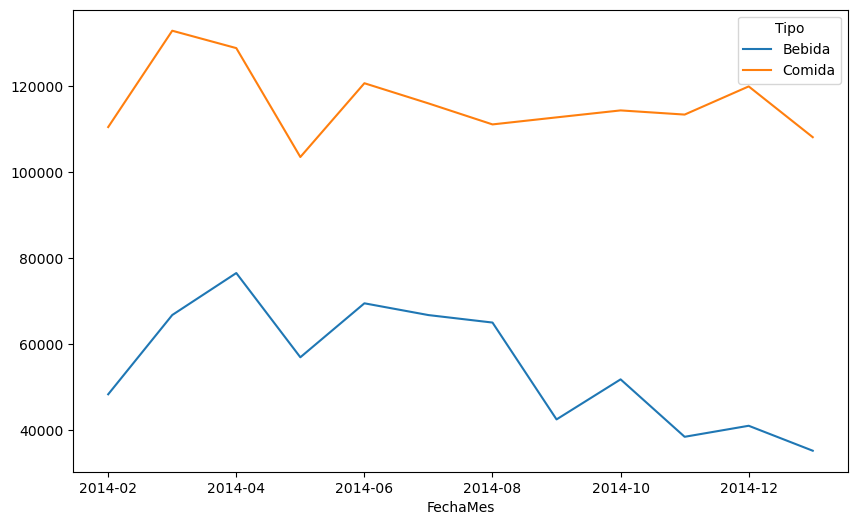

In [10]:
tipo_pivot.plot(kind= 'line', figsize=(10,6))

__Conclusión:__ los clientes piden cada vez menos bebidas, pero la comida se mantiene, por lo que tenemos fuertes indicios que el problema general se da en esa área.

Analizaremos el ingreso mensual de las bebidas teniendo una columna por categoría:

In [11]:
df_bebidas = df[df['Tipo'] == 'Bebida']
pivot_bebidas = df_bebidas.pivot_table(index='FechaMes', columns='Categoria', values='Precio', aggfunc='sum')
display(pivot_bebidas)

Categoria,Bebida no Alcohol,Cervezas,Vinos
FechaMes,,,
2014-02,15377,16145,16811
2014-03,17644,18415,30728
2014-04,16298,17170,43089
2014-05,14994,13480,28475
2014-06,16468,16360,36684
2014-07,15952,15095,35725
2014-08,15135,15155,34740
2014-09,16578,15640,10267
2014-10,16862,15590,19356


Haremos una gráfica de calor sobre los ingresos mensuales de cada tipo de bebida:

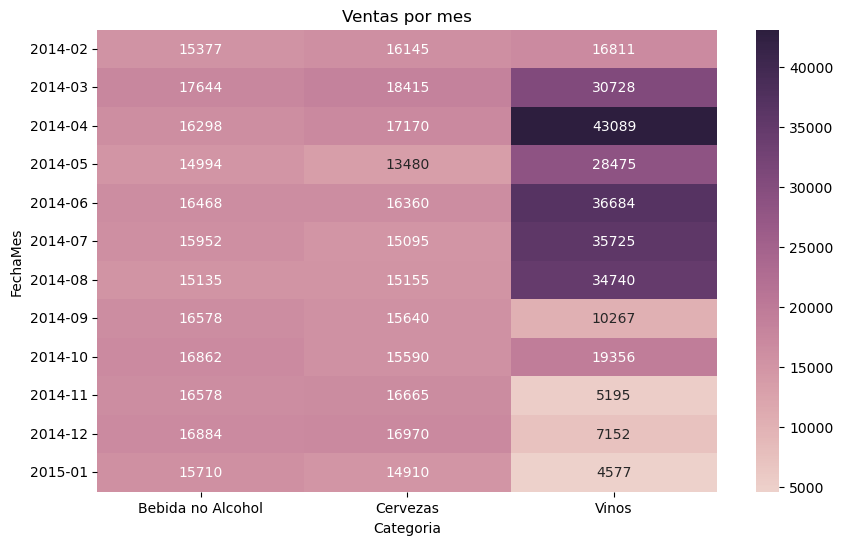

In [12]:
plt.figure(figsize=(10,6))

sns.heatmap(pivot_bebidas, annot=True, fmt='.0f', cmap= sns.cubehelix_palette(as_cmap=True))

plt.title('Ventas por mes')
plt.show()

Graficaremos el ingreso mensual de cada tipo de bebida:

<Axes: xlabel='FechaMes'>

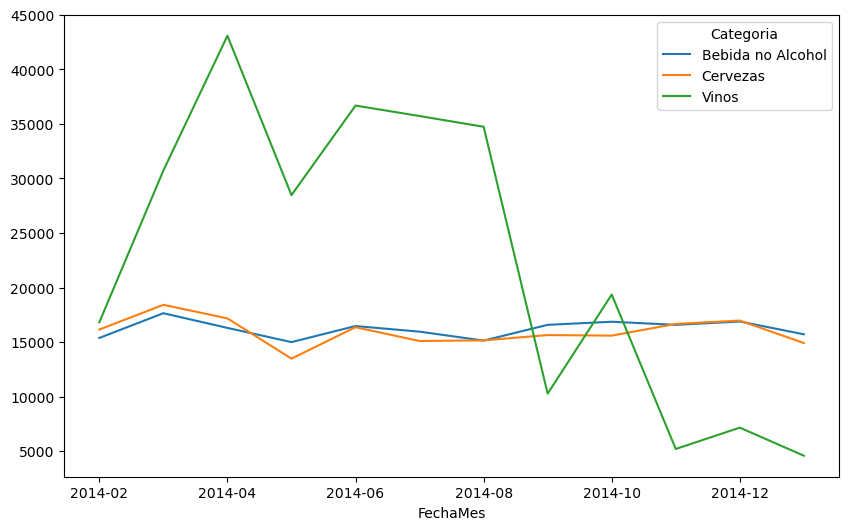

In [13]:
pivot_bebidas.plot(kind= 'line', figsize=(10,6))

__Conclusión:__ Los ingresos provenientes de los vinos bajaron mucho, debemos indagar en los posibles motivos, por ejemplo, analizando a los meseros que lo sirven.

Obtendremos las ventas mensuales de cada mesero:

In [14]:
ventas_mesero = df.pivot_table(index='FechaMes', columns='Atendió', values='Precio',aggfunc='sum')
display(ventas_mesero)

Atendió,Alejandro,Ernesto,Joel,Mariana,Mauricio,Omar,Rodolfo,Saul,Valentina
FechaMes,,,,,,,,,
2014-02,20750.0,19666.0,20447.0,29480.0,NaN,18076.0,23115.0,7260.0,20077.0
2014-03,24185.0,25380.0,29778.0,19581.0,NaN,30387.0,21735.0,22947.0,25757.0
2014-04,23956.0,19234.0,30251.0,21450.0,NaN,32231.0,34651.0,26459.0,17240.0
2014-05,24446.0,23593.0,21257.0,9166.0,NaN,21130.0,24874.0,13454.0,22596.0
2014-06,32116.0,31995.0,18699.0,29611.0,NaN,18446.0,18263.0,23672.0,17451.0
2014-07,21030.0,27139.0,34351.0,17133.0,NaN,11062.0,15017.0,33827.0,23260.0
2014-08,16371.0,17814.0,27550.0,23007.0,NaN,30738.0,18580.0,24178.0,17946.0
2014-09,17756.0,14853.0,10494.0,14024.0,30381.0,20637.0,18284.0,14109.0,14739.0
2014-10,16555.0,21821.0,25249.0,12674.0,34959.0,9201.0,15056.0,16795.0,13912.0


Haremos una gráfica de calor sobre las ventas de cada mesero:

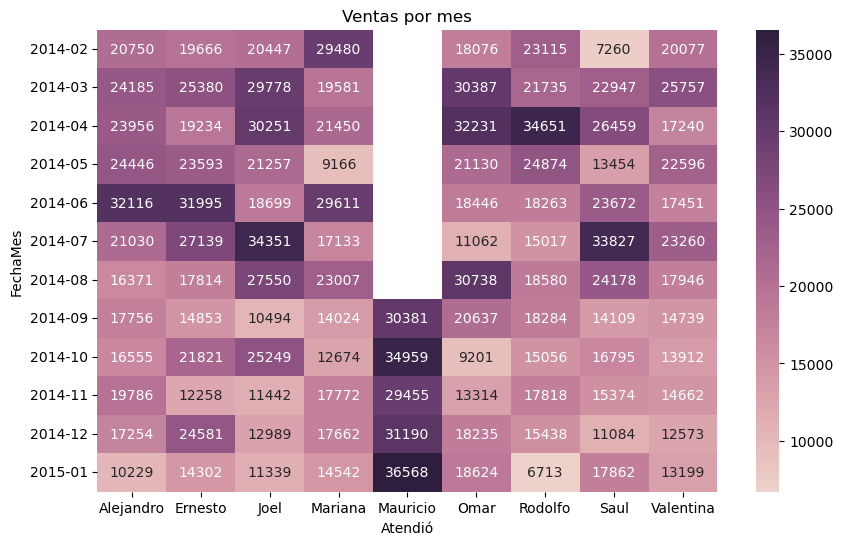

In [15]:
plt.figure(figsize=(10,6))

sns.heatmap(ventas_mesero, annot=True, fmt='.0f', cmap= sns.cubehelix_palette(as_cmap=True))

plt.title('Ventas por mes')
plt.show()

Graficaremos el ingreso por mes de cada mesero:

<Axes: xlabel='FechaMes'>

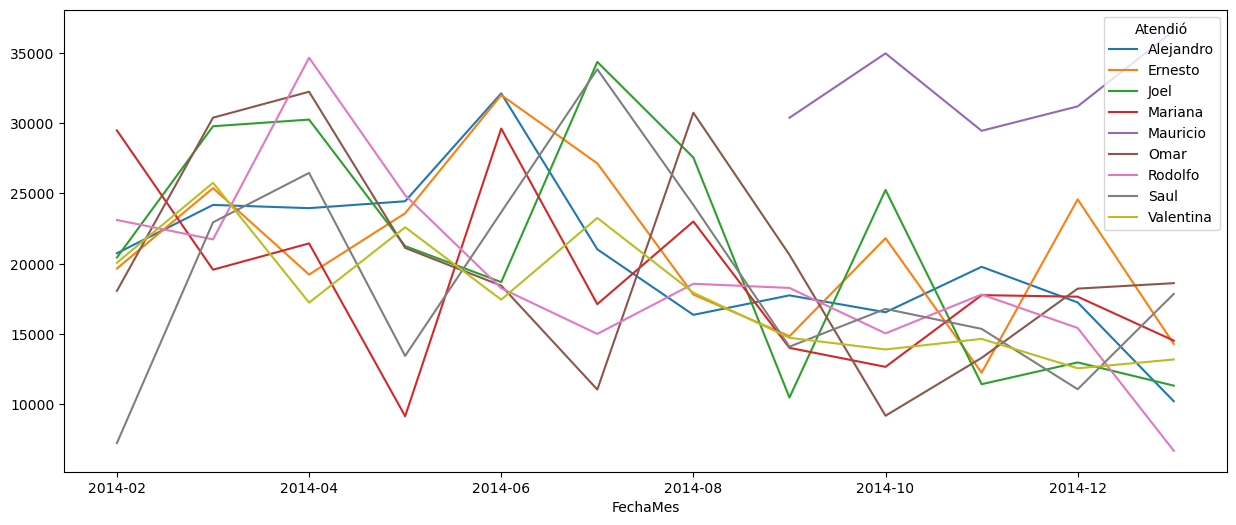

In [16]:
ventas_mesero.plot(kind='line', figsize=(15,6))

__Conclusión:__ las ventas de los meseros al igual que el vino están bajando, excepto por Mauricio que entró a trabajar en septiembre, un buen paso será graficar la relación de estas 2 variables, por ejemplo, calcular cuanto vino vende cada mesero

Averiguaremos cuanto vino vende cada mesero:

In [17]:
df_vino = df_bebidas[df_bebidas['Categoria']=='Vinos']
vino_mesero = df_vino.pivot_table(index='Atendió', values='Precio',aggfunc='sum').sort_values(by='Precio' ,ascending=False)
vino_mesero

,Precio
Atendió,
Alejandro,45957
Joel,43333
Ernesto,38776
Saul,35019
Omar,31078
Valentina,27153
Rodolfo,26233
Mariana,25250


Hacemos un análisis exploratorio con una gráfica de calor:

<Axes: ylabel='Atendió'>

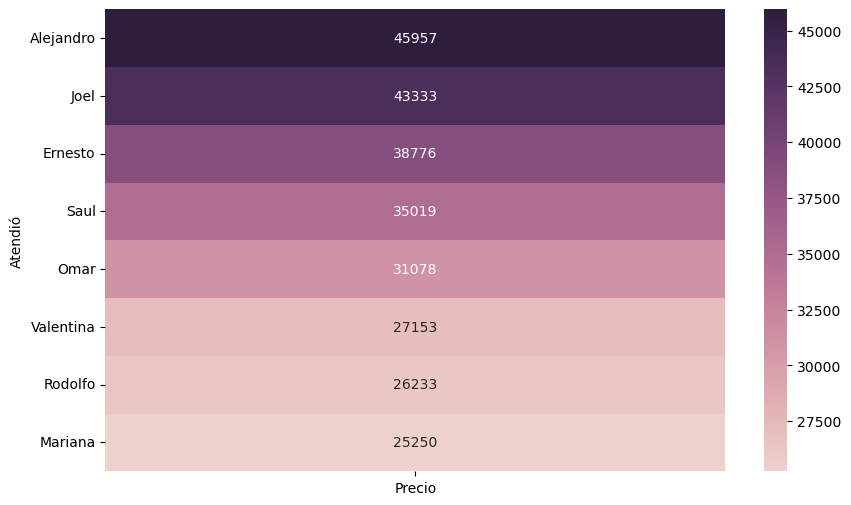

In [18]:
plt.figure(figsize=(10,6))

sns.heatmap(vino_mesero, annot=True, fmt='.0f', cmap= sns.cubehelix_palette(as_cmap=True))

Graficamos la venta de vinos de cada mesero:

<Axes: xlabel='Atendió'>

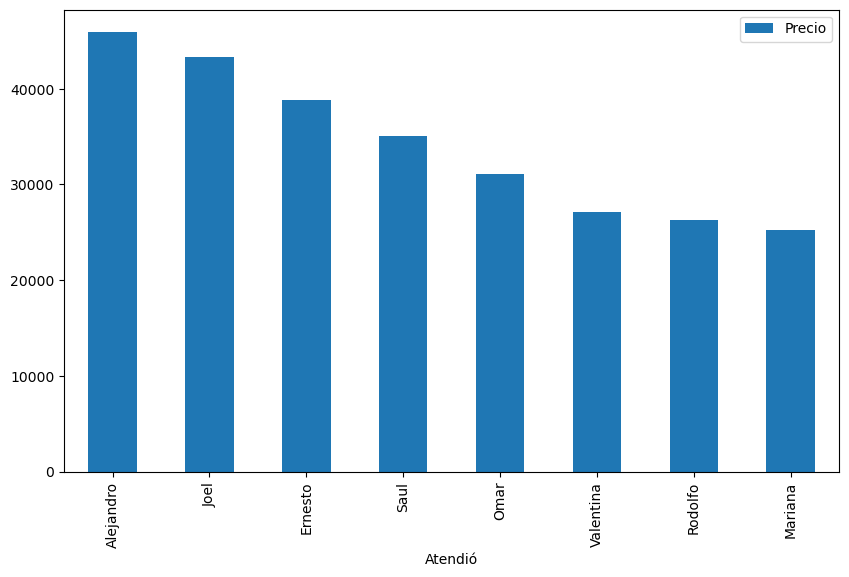

In [19]:
vino_mesero.plot(kind='bar',figsize=(10,6))

__Conclusión:__ en la gráfica anterior notamos que no aparece Mauricio, por lo que el descenso en ingresos puede deberse a esto

Para poder conocer si los meseros atienden bien utilizaremos una cantidad derivada, la propina, si reciben buenas propinas es aceptable pensar que es por su buen servicio:

In [20]:
propinas = df.pivot_table(index='Atendió', values='Propina', aggfunc='mean').sort_values(by='Propina', ascending=False)
propinas

,Propina
Atendió,
Mauricio,0.200000
Saul,0.112254
Omar,0.111976
Joel,0.111800
Ernesto,0.111613
Mariana,0.109825
Alejandro,0.107915
Rodolfo,0.107440
Valentina,0.105980


Haremos un analisis exploratorio de los datos con una gráfica de calor:

<Axes: ylabel='Atendió'>

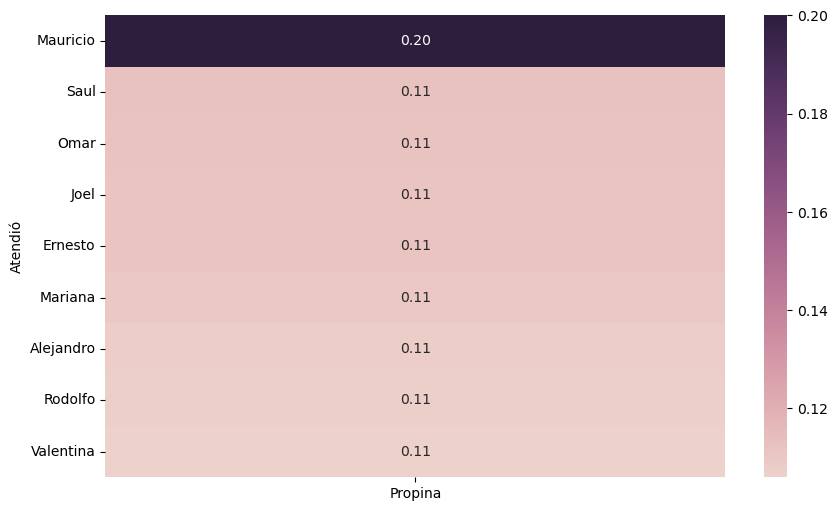

In [21]:
plt.figure(figsize=(10,6))
sns.heatmap(propinas, annot=True, fmt='.2f', cmap= sns.cubehelix_palette(as_cmap=True))

__Conclusión:__ todos los meseros tienen propinas similares, a excepción de Mauricio, por lo que debemos analizar la cantidad de clientes que vuelven a comprar con nosotros, en especial después de septiembre.

Analizaremos la cantidad de clientes nuevos contra los que regresan:

In [23]:
df.head(2)

,Orden,Fecha,Hora de Cobro,Mesa,Atendió,Tipo,Producto,Categoria,Precio,Costo,Propina,Tipo de Cliente,FechaMes
0,1,2014-02-01,18:43:12,1,Rodolfo,Bebida,Tecate,Cervezas,25,18.0,0.07,Cliente Nuevo,2014-02
1,1,2014-02-01,18:43:12,1,Rodolfo,Bebida,Tisana,Bebida no Alcohol,25,18.0,0.07,Cliente Nuevo,2014-02


In [36]:
clientes = df.pivot_table(index='FechaMes', columns='Tipo de Cliente', values='Precio', aggfunc='count')
clientes

Tipo de Cliente,Cliente Nuevo,Cliente Repetido
FechaMes,,
2014-02,1791,636
2014-03,2133,746
2014-04,1805,887
2014-05,1573,671
2014-06,1857,723
2014-07,1809,679
2014-08,1752,647
2014-09,1946,521
2014-10,1944,575


Haremos una gráfica de calor sobre las ventas al mes por tipo de cliente:

<Axes: xlabel='Tipo de Cliente', ylabel='FechaMes'>

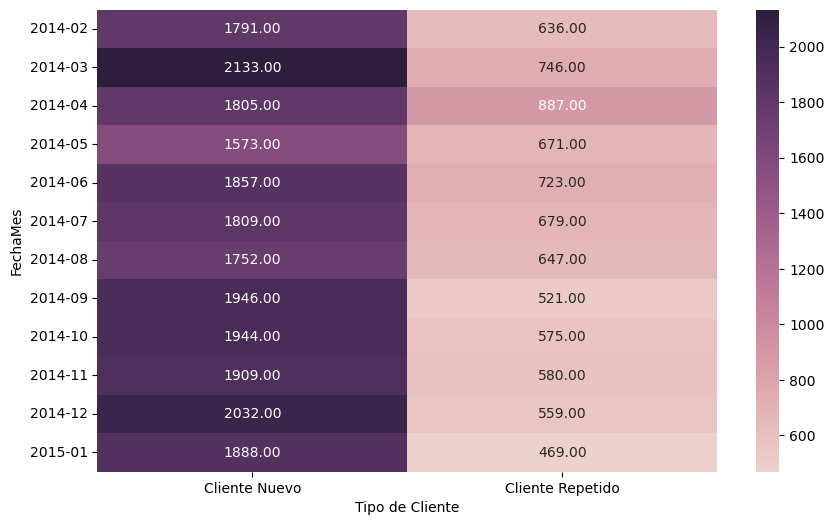

In [37]:
plt.figure(figsize=(10,6))
sns.heatmap(clientes, annot=True, fmt='.2f', cmap= sns.cubehelix_palette(as_cmap=True))

Graficaremos las ventas al mes por tipo de cliente:

<Axes: xlabel='FechaMes'>

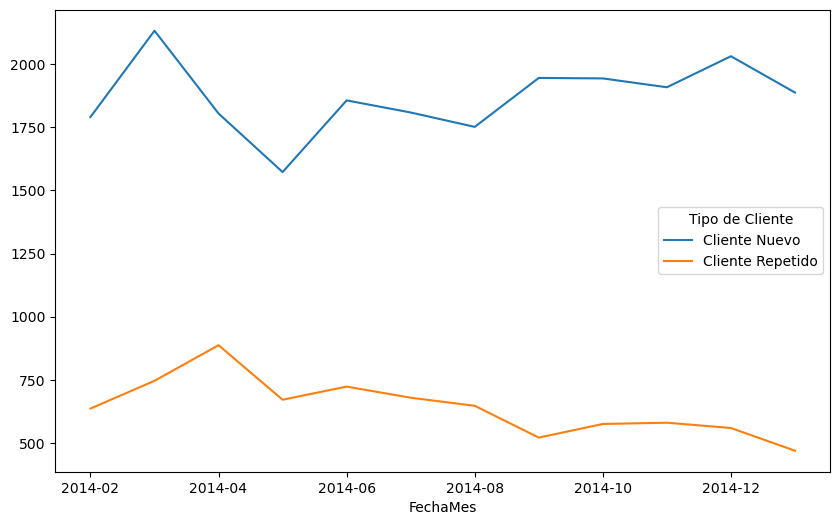

In [38]:
clientes.plot(kind='line', figsize=(10,6))

__Conclusión:__ los clientes deciden no volver a comer con nosotros, analizaremos el impacto de este hecho en la venta de vino.

Analizaremos la venta de vinos según el tipo de cliente:

In [39]:
vinos_cliente = df_vino.pivot_table(index='FechaMes', columns='Tipo de Cliente', values='Precio', aggfunc='sum')
vinos_cliente

Tipo de Cliente,Cliente Nuevo,Cliente Repetido
FechaMes,,
2014-02,3168,13643
2014-03,9389,21339
2014-04,25433,17656
2014-05,9095,19380
2014-06,17222,19462
2014-07,18964,16761
2014-08,16574,18166
2014-09,9552,715
2014-10,8372,10984


Haremos una gráfica de calor las ventas de vino al mes por tipo de cliente:

<Axes: xlabel='Tipo de Cliente', ylabel='FechaMes'>

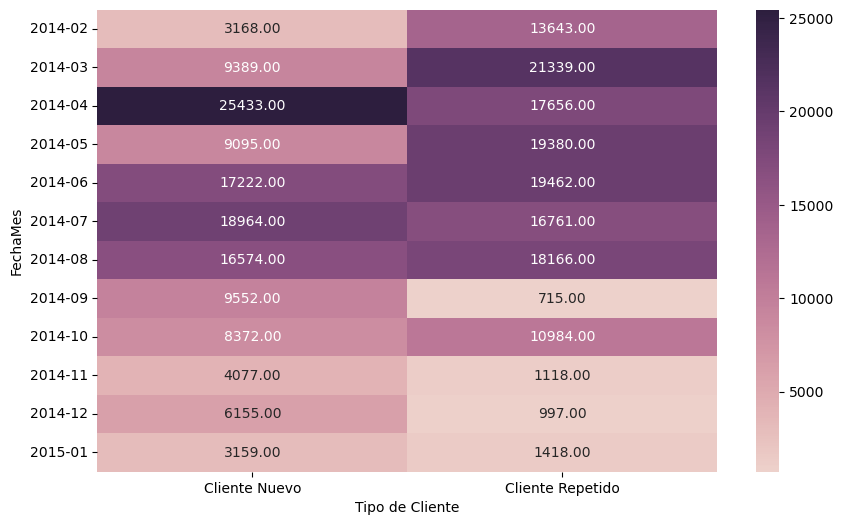

In [40]:
plt.figure(figsize=(10,6))
sns.heatmap(vinos_cliente, annot=True, fmt='.2f', cmap= sns.cubehelix_palette(as_cmap=True))

Graficaremos las ventas de vino al mes por tipo de cliente:

<Axes: xlabel='FechaMes'>

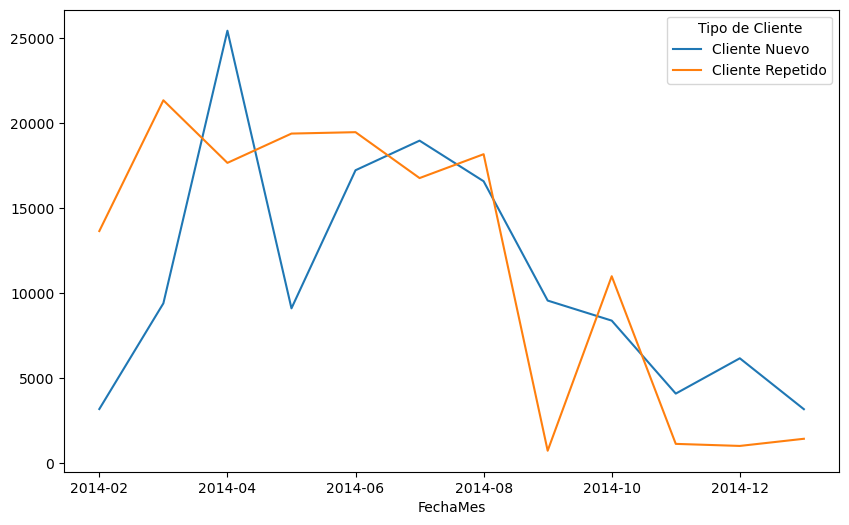

In [29]:
vinos_cliente.plot(kind='line', figsize=(10,6))

__Conclusión:__ la venta de vino en los clientes nuevos se mantuvo, pero en los repetidos ha descendido, en especial desde septiembre, debemos investigar la venta de cada mesero separado por tipo de cliente.

Analizar la venta de cada mesero en base al tipo de cliente:

In [41]:
cliente_mesero = df.pivot_table(index='Atendió', columns='Tipo de Cliente', values='Precio', aggfunc='sum').fillna(0)
cliente_mesero

Tipo de Cliente,Cliente Nuevo,Cliente Repetido
Atendió,,
Alejandro,155952.0,88482.0
Ernesto,170101.0,82535.0
Joel,188364.0,65482.0
Mariana,152285.0,73817.0
Mauricio,162553.0,0.0
Omar,152538.0,89543.0
Rodolfo,163057.0,66487.0
Saul,165294.0,61727.0
Valentina,146827.0,66585.0


Haremos un análisis exploratorio de los datos con un mapa de calor:

<Axes: xlabel='Tipo de Cliente', ylabel='Atendió'>

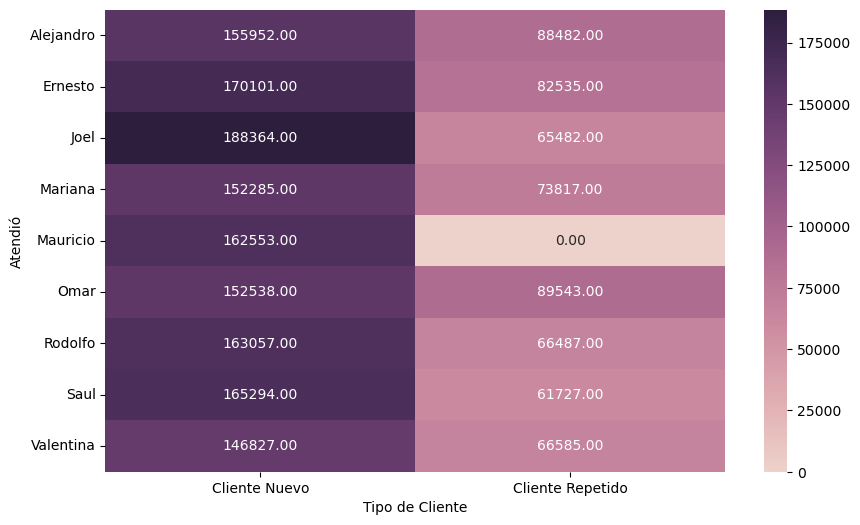

In [42]:
plt.figure(figsize=(10,6))
sns.heatmap(cliente_mesero, annot=True, fmt='.2f', cmap= sns.cubehelix_palette(as_cmap=True))


Y finalmente graficaremos las ventas al mes de cada mesero por tipo de cliente:

<Axes: xlabel='Atendió'>

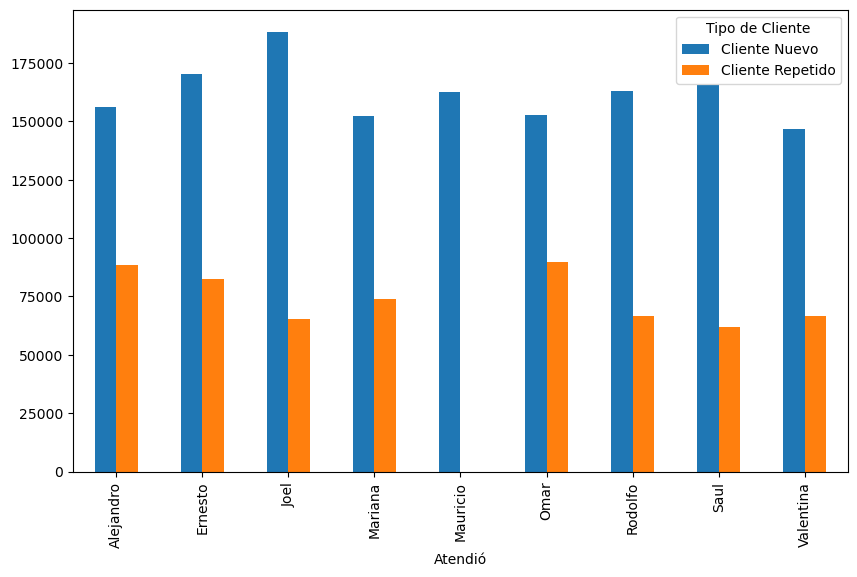

In [43]:
cliente_mesero.plot(kind='bar', figsize=(10,6))

__Conclusión:__ Mauricio no atiende clientes repetidos.

__Conlusión General:__ Los clientes repetidos son los que más vino consumían, al dejar de regresar nuestros ingresos disminuyeron, nuestro principal sospechoso es Mauricio por tener unas propinas anormalmente altas, pero pese a ello los clientes no quieren volver a ser atendidos por el.

Tras hacer una investigación presencial encontramos que la manera en la que Mauricio atendía era grosera y exigia a los comensales consumir más y cargaba propina sin avisar, por eso sus ventas eran altas, pero ahuyentaba a los clientes.